
Training with lambda = 1e-05


100%|██████████| 170M/170M [00:04<00:00, 39.9MB/s]


Epoch 1, Loss: 7067.9111
Epoch 2, Loss: 5460.8147
Epoch 3, Loss: 4392.6241
Epoch 4, Loss: 3682.6649
Epoch 5, Loss: 3200.4386
Epoch 6, Loss: 2854.2051
Epoch 7, Loss: 2594.2464
Epoch 8, Loss: 2388.0166
Epoch 9, Loss: 2220.5189
Epoch 10, Loss: 2076.2156
Epoch 11, Loss: 1953.1119
Epoch 12, Loss: 1844.2264
Epoch 13, Loss: 1746.0462
Epoch 14, Loss: 1655.7671
Epoch 15, Loss: 1574.9424
Accuracy: 55.35% | Sparsity: 18.77%

Training with lambda = 0.0001
Epoch 1, Loss: 57534.1019
Epoch 2, Loss: 38615.5044
Epoch 3, Loss: 25026.0366
Epoch 4, Loss: 16607.9035
Epoch 5, Loss: 11615.3246
Epoch 6, Loss: 8568.0963
Epoch 7, Loss: 6621.3695
Epoch 8, Loss: 5318.7097
Epoch 9, Loss: 4417.2264
Epoch 10, Loss: 3772.8106
Epoch 11, Loss: 3300.7650
Epoch 12, Loss: 2942.8492
Epoch 13, Loss: 2667.5320
Epoch 14, Loss: 2449.7106
Epoch 15, Loss: 2275.0700
Accuracy: 57.06% | Sparsity: 74.77%

Training with lambda = 0.001
Epoch 1, Loss: 562551.7433
Epoch 2, Loss: 371813.4328
Epoch 3, Loss: 232628.2557
Epoch 4, Loss: 1458

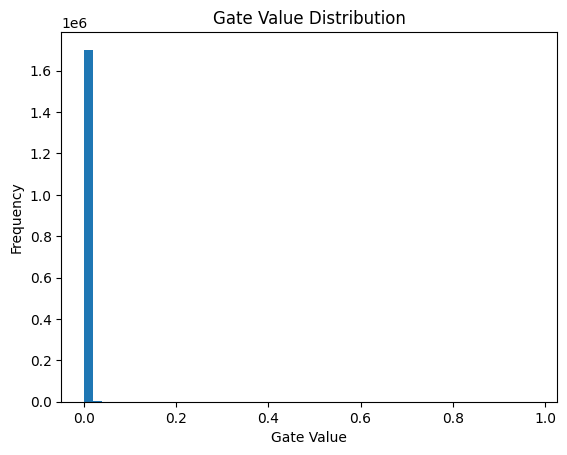

In [2]:
# self_pruning_net.py

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ================================
# 1. Prunable Linear Layer
# ================================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.02)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Learnable gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)   # values in (0,1)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)


# ================================
# 2. Neural Network
# ================================
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# ================================
# 3. Sparsity Loss
# ================================
def sparsity_loss(model):
    loss = 0.0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss


# ================================
# 4. Sparsity Metric
# ================================
def compute_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total


# ================================
# 5. Evaluation
# ================================
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100 * correct / total


# ================================
# 6. Data Loading (CIFAR-10)
# ================================
def get_data(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False
    )

    return train_loader, test_loader


# ================================
# 7. Training Function
# ================================
def train_model(lambda_sparse):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader, test_loader = get_data()

    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    epochs = 15

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_sparse * sp_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    acc = evaluate(model, test_loader, device)
    sparsity = compute_sparsity(model)

    return model, acc, sparsity


# ================================
# 8. Run Experiments
# ================================
if __name__ == "__main__":
    lambda_values = [1e-5, 1e-4, 1e-3]

    results = []

    for lam in lambda_values:
        print(f"\nTraining with lambda = {lam}")
        model, acc, sp = train_model(lam)

        print(f"Accuracy: {acc:.2f}% | Sparsity: {sp:.2f}%")
        results.append((lam, acc, sp))

    print("\nFinal Results:")
    for r in results:
        print(r)

    # ============================
    # 9. Gate Distribution Plot
    # ============================
    all_gates = []

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()